# Natural Language Processing
## Assigment 01: Urdu to Roman Urdu using LSTM and BiLSTM
## Muhammad Abu Huraira 22F-3853
## Shayan Zawar 22F-3410

# Data Preprocessing
Following techniques were used for data preprocessing:
* Data Merging
* Special character removal
* Removal of incomplete poems

Data preprocessing is mostly occured using python script 

In [ ]:
# combine all poems to one single txt files
# import os
# import glob

# def combine_ghazals_by_language(dataset_path, language, output_filename):
#     """
#     Combine all ghazals of a specific language from all poets into one text file.
    
#     Args:
#         dataset_path (str): Path to the dataset directory
#         language (str): Language code ('ur' for Urdu, 'en' for English, 'hi' for Hindi)
#         output_filename (str): Name of the output file
#     """
    
#     # Get all poet directories
#     poets_dir = os.path.join(dataset_path, 'dataset', 'dataset')
    
#     if not os.path.exists(poets_dir):
#         print(f"Error: Dataset directory not found at {poets_dir}")
#         return
    
#     # Get all poet directories
#     poet_dirs = [d for d in os.listdir(poets_dir) if os.path.isdir(os.path.join(poets_dir, d)) and not d.startswith('.')]
    
#     print(f"Found {len(poet_dirs)} poets in the dataset")
    
#     combined_content = []
#     file_count = 0
    
#     for poet in sorted(poet_dirs):
#         poet_path = os.path.join(poets_dir, poet)
#         language_path = os.path.join(poet_path, language)
        
#         if os.path.exists(language_path):
            
            
#             # Get all ghazal files for this poet in the specified language
#             ghazal_files = [f for f in os.listdir(language_path) if os.path.isfile(os.path.join(language_path, f))]
            
#             for ghazal_file in sorted(ghazal_files):
#                 file_path = os.path.join(language_path, ghazal_file)
                
#                 try:
#                     with open(file_path, 'r', encoding='utf-8') as f:
#                         content = f.read().strip()
                        
#                         if content:  # Only add non-empty files
#                             # Add poet and ghazal information as header
                            
#                             combined_content.append(" ")
#                             combined_content.append(content)

#                             file_count += 1
                            
#                 except Exception as e:
#                     print(f"Error reading file {file_path}: {e}")
#         else:
#             print(f"No {language} directory found for {poet}")
    
#     # Write combined content to output file
#     try:
#         with open(output_filename, 'w', encoding='utf-8') as f:
#             f.write("\n".join(combined_content))
        
#         print(f"\nSuccessfully combined {file_count} {language} ghazals into '{output_filename}'")
#         print(f"Total poets with {language} content: {len([p for p in poet_dirs if os.path.exists(os.path.join(poets_dir, p, language))])}")
        
#     except Exception as e:
#         print(f"Error writing output file: {e}")

# # Set the dataset path
# dataset_path = "dataset"

# print("Starting ghazal combination process...\n")

# # Combine Urdu ghazals
# print("Combining Urdu ghazals...")
# combine_ghazals_by_language(dataset_path, 'ur', 'all_urdu_ghazals.txt')

# print("\n" + "="*60 + "\n")

# # Combine English ghazals  
# print("Combining English ghazals...")
# combine_ghazals_by_language(dataset_path, 'en', 'all_english_ghazals.txt')

# print("\n" + "="*60 + "\n")
# print("All done! Check the generated files:")
# print("  all_urdu_ghazals.txt")
# print("   all_english_ghazals.txt")

In [ ]:
# # Clean/simplify transliteration: remove diacritics, dots in words, and merge hyphenated tokens
# import re
# import unicodedata
# from pathlib import Path

# # Map special punctuation to simpler forms (hyphen-like to '-') and drop ayn-like marks
# TRANSLATION_TABLE = str.maketrans({
#     "—": "-",
#     "–": "-",
#     "‑": "-",  # non-breaking hyphen
#     "‒": "-",
#     "−": "-",
#     "’": "",
#     "‘": "",
#     "ʼ": "",
#     "‛": "",
#     "ʿ": "",   # ayn mark often used in translits
# })

# def strip_diacritics(text: str) -> str:
#     # Normalize to NFKD and remove combining diacritics (e.g., ā -> a, ī -> i, ḳ -> k, ñ -> n)
#     decomposed = unicodedata.normalize("NFKD", text)
#     return "".join(ch for ch in decomposed if not unicodedata.combining(ch))

# def simplify_transliteration_line(line: str) -> str:
#     # 1) unify special punctuation, remove ayn/apostrophes
#     s = line.translate(TRANSLATION_TABLE)
#     # 2) remove diacritics
#     s = strip_diacritics(s)
#     # 3) remove periods inside words like "ga.e" -> "gae"
#     s = re.sub(r"(?<=\w)\.(?=\w)", "", s)
#     # 4) merge hyphenated tokens between letters: "tishna-labi" -> "tishnalabi", "shab-o-roz" -> "shaboroz"
#     s = re.sub(r"(?i)(?<=\w)-(?!\s)(?=\w)", "", s)
#     # 5) collapse multiple spaces; keep line breaks as-is by working per-line
#     s = re.sub(r"\s+", " ", s).strip()
#     return s


# def simplify_file(in_path: str, out_path: str) -> None:
#     total_lines = 0
#     changed_lines = 0
#     with open(in_path, "r", encoding="utf-8") as fin, open(out_path, "w", encoding="utf-8") as fout:
#         for line in fin:
#             total_lines += 1
#             cleaned = simplify_transliteration_line(line.rstrip("\n"))
#             if cleaned != line.rstrip("\n"):
#                 changed_lines += 1
#             fout.write(cleaned + "\n")
#     print(f"Simplified '{in_path}' -> '{out_path}' | lines: {total_lines:,}, changed: {changed_lines:,}")

# # Run on the combined English transliteration file
# src = "all_english_ghazals.txt"
# dst = "all_english_ghazals_clean.txt"
# if Path(src).exists():
#     simplify_file(src, dst)
# else:
#     print(f"Source not found: {src}")

In [ ]:
# # compare_poems.py

# def read_poems(file_path):
#     """Reads a file and splits it into poems (separated by blank lines)."""
#     poems = []
#     current_poem = []
#     with open(file_path, "r", encoding="utf-8") as f:
#         for line in f:
#             if line.strip() == "":
#                 if current_poem:  # poem ended
#                     poems.append(current_poem)
#                     current_poem = []
#             else:
#                 current_poem.append(line.strip())
#         if current_poem:  # add last poem if not empty
#             poems.append(current_poem)
#     return poems


# # Files
# urdu_file = "all_urdu.txt"
# roman_file = "all_english_clean.txt"

# urdu_poems = read_poems(urdu_file)
# roman_poems = read_poems(roman_file)

# print(f"Total Urdu poems: {len(urdu_poems)}")
# print(f"Total Roman poems: {len(roman_poems)}")

# # Compare poem by poem
# min_len = min(len(urdu_poems), len(roman_poems))

# for i in range(min_len):
#     urdu_lines = urdu_poems[i]
#     roman_lines = roman_poems[i]
#     if len(urdu_lines) != len(roman_lines):
#         print(f"\nPoem {i+1} mismatch:")
#         print(f"Urdu ({len(urdu_lines)} lines):")
#         print("\n".join(urdu_lines))
#         print(f"Roman Urdu ({len(roman_lines)} lines):")
#         print("\n".join(roman_lines))

# # If one file has more poems
# if len(urdu_poems) != len(roman_poems):
#     print(f"\n Extra poems detected: Urdu={len(urdu_poems)}, Roman={len(roman_poems)}")


In [3]:
# TRAIN SENTENCEPIECE TOKENIZERS WITH BPE ON TEXT FILES
import sentencepiece as spm
import os

def train_sentencepiece_tokenizers():
    """Train SentencePiece tokenizers with BPE on Urdu and Roman text files"""
    
    print(" Training SentencePiece Tokenizers with BPE...")
    
    # File paths (adjust these to your actual file locations)
    urdu_file = "/kaggle/input/urduromanurdu-cleaned/all_urdu.txt"
    roman_file = "/kaggle/input/urduromanurdu-cleaned/all_english_clean.txt"
    
    # Output tokenizer paths
    urdu_model_prefix = "/kaggle/working/urdu_tokenizer"
    roman_model_prefix = "/kaggle/working/roman_tokenizer"
    
    # Training parameters for ~5K vocabulary
    vocab_size = 5000
    
    # Train Urdu tokenizer
    print("\n Training Urdu SentencePiece tokenizer...")
    if os.path.exists(urdu_file):
        spm.SentencePieceTrainer.train(
            input=urdu_file,
            model_prefix=urdu_model_prefix,
            vocab_size=vocab_size,
            model_type='bpe',  # Use BPE algorithm
            character_coverage=0.995,  # Good for Urdu script
            split_by_unicode_script=True,  # Important for Urdu
            split_by_whitespace=True,
            normalization_rule_name='nfkc',  # Unicode normalization
            remove_extra_whitespaces=True,
            max_sentence_length=1000,
            shuffle_input_sentence=True,
            seed_sentencepiece_size=1000000,
            shrinking_factor=0.75,
            num_threads=4,
            train_extremely_large_corpus=False,
            # Special tokens
            pad_id=0,
            unk_id=1,
            bos_id=2,
            eos_id=3,
            pad_piece='<PAD>',
            unk_piece='<UNK>',
            bos_piece='<SOS>',
            eos_piece='<EOS>',
            user_defined_symbols=['<MASK>']
        )
        print(f" Urdu tokenizer trained: {urdu_model_prefix}.model")
        print(f"   Vocabulary file: {urdu_model_prefix}.vocab")
    else:
        print(f" Urdu file not found: {urdu_file}")
    
    # Train Roman Urdu tokenizer
    print("\nTraining Roman Urdu SentencePiece tokenizer...")
    if os.path.exists(roman_file):
        spm.SentencePieceTrainer.train(
            input=roman_file,
            model_prefix=roman_model_prefix,
            vocab_size=vocab_size,
            model_type='bpe',  # Use BPE algorithm
            character_coverage=1.0,  # Full coverage for Roman script
            split_by_unicode_script=False,  # Not needed for Roman
            split_by_whitespace=True,
            normalization_rule_name='nfkc',
            remove_extra_whitespaces=True,
            max_sentence_length=1000,
            shuffle_input_sentence=True,
            seed_sentencepiece_size=1000000,
            shrinking_factor=0.75,
            num_threads=4,
            train_extremely_large_corpus=False,
            # Special tokens (same IDs as Urdu for consistency)
            pad_id=0,
            unk_id=1,
            bos_id=2,
            eos_id=3,
            pad_piece='<PAD>',
            unk_piece='<UNK>',
            bos_piece='<SOS>',
            eos_piece='<EOS>',
            user_defined_symbols=['<MASK>']
        )
        print(f" Roman tokenizer trained: {roman_model_prefix}.model")
        print(f"   Vocabulary file: {roman_model_prefix}.vocab")
    else:
        print(f"Roman file not found: {roman_file}")
    
    return urdu_model_prefix + ".model", roman_model_prefix + ".model"

# Test the tokenizers
def test_tokenizers(urdu_model_path, roman_model_path):
    """Test the trained tokenizers"""
    print("\n Testing trained tokenizers...")
    
    try:
        # Load tokenizers
        urdu_sp = spm.SentencePieceProcessor()
        urdu_sp.load(urdu_model_path)
        
        roman_sp = spm.SentencePieceProcessor()
        roman_sp.load(roman_model_path)
        
        # Test sentences
        urdu_test = "تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا"
        roman_test = "tu kabhi khud ko bhi dekhega to dar jaega"
        
        print(f"\n Tokenizer Statistics:")
        print(f"Urdu vocabulary size: {urdu_sp.get_piece_size()}")
        print(f"Roman vocabulary size: {roman_sp.get_piece_size()}")
        
        print(f"\n Test Encoding/Decoding:")
        print(f"Original Urdu: {urdu_test}")
        urdu_encoded = urdu_sp.encode(urdu_test, out_type=int)
        urdu_decoded = urdu_sp.decode(urdu_encoded)
        print(f"Encoded: {urdu_encoded}")
        print(f"Decoded: {urdu_decoded}")
        
        print(f"\nOriginal Roman: {roman_test}")
        roman_encoded = roman_sp.encode(roman_test, out_type=int)
        roman_decoded = roman_sp.decode(roman_encoded)
        print(f"Encoded: {roman_encoded}")
        print(f"Decoded: {roman_decoded}")
        
        print("\n Tokenizer testing completed!")
        
    except Exception as e:
        print(f" Error testing tokenizers: {e}")

# Train the tokenizers
print(" Starting SentencePiece BPE Training Process...")
urdu_model_path, roman_model_path = train_sentencepiece_tokenizers()

# Test the trained tokenizers
test_tokenizers(urdu_model_path, roman_model_path)

print("\n SentencePiece tokenizers with BPE successfully trained!")
print(" Model files created:")
print(f"   - Urdu: /kaggle/working/urdu_tokenizer.model")
print(f"   - Roman: /kaggle/working/roman_tokenizer.model")
print(" These tokenizers are now ready for use in the architectures below!")

 Starting SentencePiece BPE Training Process...
 Training SentencePiece Tokenizers with BPE...

 Training Urdu SentencePiece tokenizer...
 Urdu tokenizer trained: /kaggle/working/urdu_tokenizer.model
   Vocabulary file: /kaggle/working/urdu_tokenizer.vocab

Training Roman Urdu SentencePiece tokenizer...
 Roman tokenizer trained: /kaggle/working/roman_tokenizer.model
   Vocabulary file: /kaggle/working/roman_tokenizer.vocab

 Testing trained tokenizers...

 Tokenizer Statistics:
Urdu vocabulary size: 5000
Roman vocabulary size: 5000

 Test Encoding/Decoding:
Original Urdu: تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا
Encoded: [38, 181, 224, 27, 46, 1101, 171, 38, 4961, 1, 4966, 176, 171]
Decoded: تو کبھی خود کو بھی دیکھے گا تو  ⁇ ر جائے گا

Original Roman: tu kabhi khud ko bhi dekhega to dar jaega
Encoded: [99, 231, 367, 36, 60, 1625, 94, 62, 149, 2074]
Decoded: tu kabhi khud ko bhi dekhega to dar jaega

 Tokenizer testing completed!

 SentencePiece tokenizers with BPE successfully trained

# Model Creation and Training

In [4]:
!pip install sentencepiece editdistance nltk editdistance gensim --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 48.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.


In [10]:
# CHUNK 0 - THREE ARCHITECTURE CONFIGURATIONS
import os, random, time, math
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import sentencepiece as spm
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE ->", DEVICE) 

# THREE DIFFERENT ARCHITECTURES FOR EXPERIMENTATION
ARCHITECTURES = {
    "ARCH_1": {
        "name": "Architecture 1 - Base Configuration",
        "roman_txt": "/kaggle/input/urduromanurdu-cleaned/all_english_clean.txt",
        "urdu_txt": "/kaggle/input/urduromanurdu-cleaned/all_urdu.txt",
        "roman_spm": "/kaggle/working/roman_tokenizer.model",
        "urdu_spm": "/kaggle/working/urdu_tokenizer.model",
        
        # Model Architecture
        "embed_dim": 128,           # First embedding dimension
        "hidden_size": 256,         # First hidden size
        "encoder_layers": 2,        # BiLSTM encoder layers
        "decoder_layers": 4,        # LSTM decoder layers
        
        # Training parameters
        "batch_size": 32,
        "learning_rate": 1e-3,
        "dropout": 0.1,
        "num_epochs": 30,
        "patience": 5,
        
        # Data preprocessing
        "max_len": 100,
        "min_len": 5,
        "vocab_size_src": 2500,
        "vocab_size_tgt": 2500,
        
        # Training dynamics
        "teacher_start": 0.9,
        "teacher_end": 0.5,
        "teacher_decay": 0.99,
        "warmup_steps": 1000,
        "max_grad_norm": 1.0,
        "label_smoothing": 0.1,
        "weight_decay": 1e-4,
        "num_workers": 2,
        "seed": 42,
    },
    
    "ARCH_2": {
        "name": "Architecture 2 - Enhanced Configuration",
        "roman_txt": "/kaggle/input/urduromanurdu-cleaned/all_english_clean.txt",
        "urdu_txt": "/kaggle/input/urduromanurdu-cleaned/all_urdu.txt",
        "roman_spm": "/kaggle/working/roman_tokenizer.model",
        "urdu_spm": "/kaggle/working/urdu_tokenizer.model",
        
        "embed_dim": 256,           # Second embedding dimension
        "hidden_size": 512,         # Second hidden size
        "encoder_layers": 3,        # More BiLSTM encoder layers
        "decoder_layers": 3,        # Different decoder layers
        
        # Training parameters
        "batch_size": 64,           # Different batch size
        "learning_rate": 5e-4,      
        "dropout": 0.3,             # Different dropout
        "num_epochs": 30,
        "patience": 5,
        
        # Data preprocessing
        "max_len": 100,
        "min_len": 5,
        "vocab_size_src": 2500,
        "vocab_size_tgt": 2500,
        
        # Training dynamics
        "teacher_start": 0.9,
        "teacher_end": 0.3,
        "teacher_decay": 0.95,
        "warmup_steps": 1000,
        "max_grad_norm": 1.0,
        "label_smoothing": 0.1,
        "weight_decay": 1e-4,
        "num_workers": 2,
        "seed": 42,
    },
    
    "ARCH_3": {
        "name": "Architecture 3 - Advanced Configuration",
        "roman_txt": "/kaggle/input/urduromanurdu-cleaned/all_english_clean.txt",
        "urdu_txt": "/kaggle/input/urduromanurdu-cleaned/all_urdu.txt",
          "roman_spm": "/kaggle/working/roman_tokenizer.model",
        "urdu_spm": "/kaggle/working/urdu_tokenizer.model",
        
        # Model Architecture - Third set of parameters
        "embed_dim": 512,           # Third embedding dimension
        "hidden_size": 512,         # Same hidden size as arch2
        "encoder_layers": 1,        # Fewer encoder layers
        "decoder_layers": 2,        # Fewer decoder layers
        
        # Training parameters
        "batch_size": 128,          # Large batch size
        "learning_rate": 1e-4,      
        "dropout": 0.5,             # Highest dropout
        "num_epochs": 30,
        "patience": 5,
        
        # Data preprocessing
        "max_len": 100,
        "min_len": 5,
        "vocab_size_src": 2500,
        "vocab_size_tgt": 2500,
        
        # Training dynamics
        "teacher_start": 0.9,
        "teacher_end": 0.3,
        "teacher_decay": 0.95,
        "warmup_steps": 1000,
        "max_grad_norm": 1.0,
        "label_smoothing": 0.1,
        "weight_decay": 1e-4,
        "num_workers": 2,
        "seed": 42,
    }
}

# Set seed for reproducibility
import random, torch
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("Three architectures configured!")
print(f"Architecture 1: Embed={ARCHITECTURES['ARCH_1']['embed_dim']}, Hidden={ARCHITECTURES['ARCH_1']['hidden_size']}, Enc={ARCHITECTURES['ARCH_1']['encoder_layers']}, Dec={ARCHITECTURES['ARCH_1']['decoder_layers']}")
print(f"Architecture 2: Embed={ARCHITECTURES['ARCH_2']['embed_dim']}, Hidden={ARCHITECTURES['ARCH_2']['hidden_size']}, Enc={ARCHITECTURES['ARCH_2']['encoder_layers']}, Dec={ARCHITECTURES['ARCH_2']['decoder_layers']}")
print(f"Architecture 3: Embed={ARCHITECTURES['ARCH_3']['embed_dim']}, Hidden={ARCHITECTURES['ARCH_3']['hidden_size']}, Enc={ARCHITECTURES['ARCH_3']['encoder_layers']}, Dec={ARCHITECTURES['ARCH_3']['decoder_layers']}")

print("Run completed")

DEVICE -> cuda
Three architectures configured!
Architecture 1: Embed=128, Hidden=256, Enc=2, Dec=4
Architecture 2: Embed=256, Hidden=512, Enc=3, Dec=3
Architecture 3: Embed=512, Hidden=512, Enc=1, Dec=2
Run completed


In [11]:
# Chunk 1: LOADING PRE-TRAINED TOKENIZERS FROM KAGGLE
import sentencepiece as spm
import os

# Check if tokenizer files exist for all architectures
for arch_name, config in ARCHITECTURES.items():
    print(f"\nChecking tokenizers for {arch_name} ===")
    
    urdu_tokenizer_path = config["urdu_spm"]
    roman_tokenizer_path = config["roman_spm"]
    
    if os.path.exists(urdu_tokenizer_path):
        print(f"Urdu tokenizer found: {urdu_tokenizer_path}")
    else:
        print(f"Urdu tokenizer not found: {urdu_tokenizer_path}")
    
    if os.path.exists(roman_tokenizer_path):
        print(f"Roman tokenizer found: {roman_tokenizer_path}")
    else:
        print(f"Roman tokenizer not found: {roman_tokenizer_path}")

print("\nTokenizer check completed! All architectures will use the same pre-trained tokenizers.")


Checking tokenizers for ARCH_1 ===
Urdu tokenizer found: /kaggle/working/urdu_tokenizer.model
Roman tokenizer found: /kaggle/working/roman_tokenizer.model

Checking tokenizers for ARCH_2 ===
Urdu tokenizer found: /kaggle/working/urdu_tokenizer.model
Roman tokenizer found: /kaggle/working/roman_tokenizer.model

Checking tokenizers for ARCH_3 ===
Urdu tokenizer found: /kaggle/working/urdu_tokenizer.model
Roman tokenizer found: /kaggle/working/roman_tokenizer.model

Tokenizer check completed! All architectures will use the same pre-trained tokenizers.


In [12]:
# Chunk 2: DATA LOADING WITH 50-25-25 SPLIT FOR ALL ARCHITECTURES
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm

def load_and_prepare_data(config, arch_name):
    """Load and prepare data for a specific architecture with 50-25-25 split"""
    print(f"\n=== Preparing data for {arch_name} ===")
    
    # Load tokenizers
    urdu_sp = spm.SentencePieceProcessor()
    urdu_sp.load(config["urdu_spm"])
    roman_sp = spm.SentencePieceProcessor()
    roman_sp.load(config["roman_spm"])

    # Define token IDs
    SRC_PAD = urdu_sp.pad_id()
    TGT_PAD = roman_sp.pad_id()
    BOS_ID = roman_sp.bos_id()
    EOS_ID = roman_sp.eos_id()

    print(f"Vocab sizes: Urdu={urdu_sp.get_piece_size()}, Roman={roman_sp.get_piece_size()}")

    # Read data
    with open(config["urdu_txt"], "r", encoding="utf-8") as f:
        urdu_lines = [line.strip() for line in f if line.strip()]

    with open(config["roman_txt"], "r", encoding="utf-8") as f:  
        roman_lines = [line.strip() for line in f if line.strip()]

    print(f"Raw lines: Urdu={len(urdu_lines)}, Roman={len(roman_lines)}")
    assert len(urdu_lines) == len(roman_lines), "Misaligned data!"

    # Filter pairs
    def is_valid_pair(urdu_text, roman_text):
        if len(urdu_text.split()) > config["max_len"] or len(roman_text.split()) > config["max_len"]:
            return False
        if len(urdu_text.split()) < config["min_len"] or len(roman_text.split()) < config["min_len"]:
            return False
        
        urdu_ids = urdu_sp.encode(urdu_text, out_type=int)
        roman_ids = roman_sp.encode(roman_text, out_type=int)
        
        if len(urdu_ids) == 0 or len(roman_ids) == 0:
            return False
        if len(urdu_ids) > config["max_len"] or len(roman_ids) > config["max_len"]:
            return False
        
        return True

    # Create valid pairs
    valid_pairs = []
    for urdu, roman in zip(urdu_lines, roman_lines):
        if is_valid_pair(urdu, roman):
            valid_pairs.append((urdu, roman))

    print(f"Valid pairs after filtering: {len(valid_pairs)}")

    # 50-25-25 Split with shuffling
    import random
    random.shuffle(valid_pairs)

    n = len(valid_pairs)
    train_end = int(0.5 * n)    # 50% train
    valid_end = int(0.75 * n)   # 25% valid, 25% test

    train_pairs = valid_pairs[:train_end]
    valid_pairs_split = valid_pairs[train_end:valid_end]  
    test_pairs = valid_pairs[valid_end:]

    print(f"Data splits: train={len(train_pairs)} (50%), valid={len(valid_pairs_split)} (25%), test={len(test_pairs)} (25%)")
    
    return {
        'train_pairs': train_pairs,
        'valid_pairs': valid_pairs_split,
        'test_pairs': test_pairs,
        'urdu_sp': urdu_sp,
        'roman_sp': roman_sp,
        'SRC_PAD': SRC_PAD,
        'TGT_PAD': TGT_PAD,
        'BOS_ID': BOS_ID,
        'EOS_ID': EOS_ID
    }

class ImprovedDataset(Dataset):
    def __init__(self, pairs, src_sp, tgt_sp, max_len, bos_id, eos_id):
        self.pairs = pairs
        self.src_sp = src_sp
        self.tgt_sp = tgt_sp 
        self.max_len = max_len
        self.bos_id = bos_id
        self.eos_id = eos_id
        
    def __len__(self):
        return len(self.pairs)
        
    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]
        
        # Tokenize
        src_ids = self.src_sp.encode(src_text, out_type=int)
        tgt_ids = self.tgt_sp.encode(tgt_text, out_type=int)
        
        # Truncate if needed
        src_ids = src_ids[:self.max_len-2]
        tgt_ids = tgt_ids[:self.max_len-2]
        
        # Add special tokens for target
        tgt_input = [self.bos_id] + tgt_ids
        tgt_output = tgt_ids + [self.eos_id] 
        
        return {
            'src': torch.tensor(src_ids, dtype=torch.long),
            'tgt_input': torch.tensor(tgt_input, dtype=torch.long),
            'tgt_output': torch.tensor(tgt_output, dtype=torch.long),
            'src_len': len(src_ids),
            'tgt_len': len(tgt_ids) + 1
        }

def create_collate_fn(src_pad, tgt_pad):
    """Create collate function with specific padding tokens"""
    def collate_fn(batch):
        if len(batch) == 0:
            return None
            
        srcs = [item['src'] for item in batch]
        tgt_inputs = [item['tgt_input'] for item in batch] 
        tgt_outputs = [item['tgt_output'] for item in batch]
        src_lens = torch.tensor([item['src_len'] for item in batch], dtype=torch.long)
        
        src_padded = pad_sequence(srcs, batch_first=True, padding_value=src_pad)
        tgt_input_padded = pad_sequence(tgt_inputs, batch_first=True, padding_value=tgt_pad)
        tgt_output_padded = pad_sequence(tgt_outputs, batch_first=True, padding_value=tgt_pad)
        
        return {
            'src': src_padded,
            'tgt_input': tgt_input_padded, 
            'tgt_output': tgt_output_padded,
            'src_lens': src_lens
        }
    return collate_fn

def create_data_loaders(data_dict, config):
    """Create data loaders for a specific architecture"""
    
    # Create datasets
    train_dataset = ImprovedDataset(
        data_dict['train_pairs'], data_dict['urdu_sp'], data_dict['roman_sp'], 
        config["max_len"], data_dict['BOS_ID'], data_dict['EOS_ID']
    )
    valid_dataset = ImprovedDataset(
        data_dict['valid_pairs'], data_dict['urdu_sp'], data_dict['roman_sp'], 
        config["max_len"], data_dict['BOS_ID'], data_dict['EOS_ID']
    )
    test_dataset = ImprovedDataset(
        data_dict['test_pairs'], data_dict['urdu_sp'], data_dict['roman_sp'], 
        config["max_len"], data_dict['BOS_ID'], data_dict['EOS_ID']
    )

    # Create collate function
    collate_fn = create_collate_fn(data_dict['SRC_PAD'], data_dict['TGT_PAD'])

    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config["batch_size"],
        shuffle=True,
        collate_fn=collate_fn,
        pin_memory=True,
        num_workers=config["num_workers"]
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=config["batch_size"], 
        shuffle=False,
        collate_fn=collate_fn,
        pin_memory=True,
        num_workers=config["num_workers"]
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    return train_loader, valid_loader, test_loader

# Prepare data for all architectures
ALL_DATA = {}
for arch_name, config in ARCHITECTURES.items():
    ALL_DATA[arch_name] = load_and_prepare_data(config, arch_name)

print("\nData preparation completed for all architectures!")
print("Data splits are 50% train, 25% validation, 25% test as requested.")


=== Preparing data for ARCH_1 ===
Vocab sizes: Urdu=5000, Roman=5000
Raw lines: Urdu=21000, Roman=21000
Valid pairs after filtering: 19515
Data splits: train=9757 (50%), valid=4879 (25%), test=4879 (25%)

=== Preparing data for ARCH_2 ===
Vocab sizes: Urdu=5000, Roman=5000
Raw lines: Urdu=21000, Roman=21000
Valid pairs after filtering: 19515
Data splits: train=9757 (50%), valid=4879 (25%), test=4879 (25%)

=== Preparing data for ARCH_3 ===
Vocab sizes: Urdu=5000, Roman=5000
Raw lines: Urdu=21000, Roman=21000
Valid pairs after filtering: 19515
Data splits: train=9757 (50%), valid=4879 (25%), test=4879 (25%)

Data preparation completed for all architectures!
Data splits are 50% train, 25% validation, 25% test as requested.


In [13]:
# Chunk 3: MODEL ARCHITECTURES FOR ALL THREE CONFIGURATIONS
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import math

class ImprovedEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout, src_pad):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=src_pad)
        self.rnn = nn.LSTM(
            embed_dim, hidden_dim, n_layers, 
            batch_first=True, bidirectional=True, 
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))

        # deals with src and trg sen padding 
        packed = pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        packed_outputs, (hidden, cell) = self.rnn(packed)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)
        
        return outputs, (hidden, cell)

class ImprovedDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout, tgt_pad):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tgt_pad)
        
        self.rnn = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        
        self.output_projection = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_token, hidden, cell):
        embedded = self.dropout(self.embedding(input_token))
        rnn_output, (new_hidden, new_cell) = self.rnn(embedded, (hidden, cell))
        output = self.output_projection(rnn_output.squeeze(1))
        return output, (new_hidden, new_cell)

class ImprovedSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder  
        self.device = device
        
        # Fixed projection layers to handle bidirectional encoder properly
        encoder_hidden_size = encoder.rnn.hidden_size * 2  # bidirectional
        decoder_hidden_size = decoder.rnn.hidden_size
        decoder_num_layers = decoder.rnn.num_layers
        
        # Project from bidirectional encoder to decoder dimensions
        self.hidden_projection = nn.Linear(encoder_hidden_size, decoder_hidden_size)
        self.cell_projection = nn.Linear(encoder_hidden_size, decoder_hidden_size)
        
    def init_decoder_states(self, encoder_hidden, encoder_cell):
        """Initialize decoder states from encoder final states - FIXED VERSION"""
        # encoder_hidden shape: (encoder_layers * 2, batch, encoder_hidden_size)
        # encoder_cell shape: (encoder_layers * 2, batch, encoder_hidden_size) 
        # We need: (decoder_layers, batch, decoder_hidden_size)
        
        batch_size = encoder_hidden.size(1)
        encoder_layers = encoder_hidden.size(0) // 2  # divide by 2 for bidirectional
        decoder_layers = self.decoder.rnn.num_layers
        
        # Take the final forward and backward hidden states
        # Forward: encoder_hidden[encoder_layers-1] 
        # Backward: encoder_hidden[encoder_layers*2-1]
        final_forward_h = encoder_hidden[encoder_layers - 1]  # Last forward layer
        final_backward_h = encoder_hidden[-1]  # Last backward layer (encoder_layers*2 - 1)
        
        final_forward_c = encoder_cell[encoder_layers - 1] 
        final_backward_c = encoder_cell[-1]
        
        # Concatenate forward and backward
        final_h = torch.cat([final_forward_h, final_backward_h], dim=1)
        final_c = torch.cat([final_forward_c, final_backward_c], dim=1)
        
        # Project to decoder dimensions
        projected_h = self.hidden_projection(final_h)  # (batch, decoder_hidden_size)
        projected_c = self.cell_projection(final_c)    # (batch, decoder_hidden_size)
        
        # Repeat for all decoder layers
        decoder_hidden = projected_h.unsqueeze(0).repeat(decoder_layers, 1, 1)
        decoder_cell = projected_c.unsqueeze(0).repeat(decoder_layers, 1, 1)
        
        return decoder_hidden, decoder_cell
        
    def forward(self, src, src_lengths, tgt_input, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt_input.size(1)
        vocab_size = self.decoder.output_projection.out_features
        
        encoder_outputs, (encoder_hidden, encoder_cell) = self.encoder(src, src_lengths)
        decoder_hidden, decoder_cell = self.init_decoder_states(encoder_hidden, encoder_cell)
        
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)
        input_token = tgt_input[:, 0:1]
        
        for t in range(1, tgt_len):
            output, (decoder_hidden, decoder_cell) = self.decoder(
                input_token, decoder_hidden, decoder_cell
            )
            
            outputs[:, t] = output
            
            if random.random() < teacher_forcing_ratio:
                input_token = tgt_input[:, t:t+1]
            else:
                input_token = output.argmax(dim=-1, keepdim=True)
                
        return outputs

def create_model_for_architecture(config, data_dict, arch_name):
    """Create model for a specific architecture"""
    print(f"\n=== Creating model for {arch_name} ===")
    
    encoder = ImprovedEncoder(
        vocab_size=data_dict['urdu_sp'].get_piece_size(),
        embed_dim=config["embed_dim"],
        hidden_dim=config["hidden_size"], 
        n_layers=config["encoder_layers"],
        dropout=config["dropout"],
        src_pad=data_dict['SRC_PAD']
    )

    decoder = ImprovedDecoder(
        vocab_size=data_dict['roman_sp'].get_piece_size(),
        embed_dim=config["embed_dim"],
        hidden_dim=config["hidden_size"],
        n_layers=config["decoder_layers"],
        dropout=config["dropout"],
        tgt_pad=data_dict['TGT_PAD']
    )

    model = ImprovedSeq2Seq(encoder, decoder, DEVICE).to(DEVICE)
    
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    param_count = count_parameters(model)
    print(f"{arch_name} has {param_count:,} trainable parameters")
    print(f"Config: Embed={config['embed_dim']}, Hidden={config['hidden_size']}, Enc_layers={config['encoder_layers']}, Dec_layers={config['decoder_layers']}")
    
    return model

# Create models for all architectures
ALL_MODELS = {}
for arch_name, config in ARCHITECTURES.items():
    ALL_MODELS[arch_name] = create_model_for_architecture(config, ALL_DATA[arch_name], arch_name)

print(f"\nAll three models created successfully!")
print("Architecture comparison:")
for arch_name in ARCHITECTURES.keys():
    config = ARCHITECTURES[arch_name]
    print(f"{arch_name}: {config['embed_dim']}-{config['hidden_size']}-{config['encoder_layers']}-{config['decoder_layers']} | Batch: {config['batch_size']} | LR: {config['learning_rate']} | Dropout: {config['dropout']}")

import random


=== Creating model for ARCH_1 ===
ARCH_1 has 7,169,416 trainable parameters
Config: Embed=128, Hidden=256, Enc_layers=2, Dec_layers=4

=== Creating model for ARCH_2 ===
ARCH_2 has 27,707,272 trainable parameters
Config: Embed=256, Hidden=512, Enc_layers=3, Dec_layers=3

=== Creating model for ARCH_3 ===
ARCH_3 has 17,139,592 trainable parameters
Config: Embed=512, Hidden=512, Enc_layers=1, Dec_layers=2

All three models created successfully!
Architecture comparison:
ARCH_1: 128-256-2-4 | Batch: 32 | LR: 0.001 | Dropout: 0.1
ARCH_2: 256-512-3-3 | Batch: 64 | LR: 0.0005 | Dropout: 0.3
ARCH_3: 512-512-1-2 | Batch: 128 | LR: 0.0001 | Dropout: 0.5


# Training of all 3 Architectures
all architectures used 50 % train 25% validation and  25% testing split. 

In [15]:
# Chunk 4: TRAINING FUNCTION FOR ALL THREE ARCHITECTURES
import torch
import torch.optim as optim
import math
import time
from collections.abc import Mapping
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


def train_architecture(arch_name, model, config, data_dict, best_model_from_previous=None):
    """Train a single architecture"""
    print(f"\n{'='*80}")
    print(f"TRAINING {arch_name.upper()}")
    print(f"{'='*80}")

    # Load best model from previous architecture if available
    if best_model_from_previous is not None:
        print("Loading best model from previous architecture (safe partial load)...")
        prev_state = best_model_from_previous

        # If we were given a checkpoint path, try to read it
        if isinstance(prev_state, str):
            try:
                checkpoint = torch.load(prev_state, map_location='cpu')
                prev_state = checkpoint.get('model_state_dict', checkpoint)
            except (OSError, RuntimeError) as exc:
                print(f"  Could not load checkpoint from '{prev_state}': {exc}")
                prev_state = None

        # If we were given a checkpoint dict, extract its state_dict field
        if isinstance(prev_state, Mapping) and 'model_state_dict' in prev_state and isinstance(prev_state['model_state_dict'], Mapping):
            prev_state = prev_state['model_state_dict']

        if isinstance(prev_state, Mapping):
            current_state = model.state_dict()
            loaded_exact = 0
            loaded_partial = 0
            skipped = []

            for key, prev_tensor in prev_state.items():
                if key not in current_state:
                    skipped.append(key)
                    continue

                cur_tensor = current_state[key]
                if not isinstance(prev_tensor, torch.Tensor):
                    skipped.append(key)
                    continue

                prev_cpu = prev_tensor.detach().cpu()
                cur_cpu = cur_tensor.detach().cpu()

                if prev_cpu.dtype != cur_cpu.dtype:
                    try:
                        prev_cpu = prev_cpu.to(cur_cpu.dtype)
                    except RuntimeError:
                        skipped.append(key)
                        continue

                if prev_cpu.shape == cur_cpu.shape:
                    current_state[key] = prev_cpu.to(cur_tensor.device)
                    loaded_exact += 1
                    continue

                if prev_cpu.ndim == 0 or cur_cpu.ndim == 0 or len(prev_cpu.shape) != len(cur_cpu.shape):
                    skipped.append(key)
                    continue

                try:
                    min_shape = tuple(min(p, c) for p, c in zip(prev_cpu.shape, cur_cpu.shape))
                    slices = tuple(slice(0, m) for m in min_shape)
                    cur_cpu[slices] = prev_cpu[slices]
                    current_state[key] = cur_cpu.to(cur_tensor.device)
                    loaded_partial += 1
                except Exception:
                    skipped.append(key)

            model.load_state_dict(current_state, strict=False)
            print(f"  Loaded {loaded_exact} tensors exactly, {loaded_partial} partially; skipped {len(skipped)}")
            if skipped and len(skipped) <= 10:
                print("  Skipped keys:", skipped)
        else:
            print("  Previous model state isn't compatible; training will start from scratch.")

    # Create data loaders
    train_loader, valid_loader, test_loader = create_data_loaders(data_dict, config)

    # Optimizer and scheduler
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
        betas=(0.9, 0.98),
        eps=1e-9
    )

    def get_lr_scheduler(optimizer, warmup_steps, total_steps):
        def lr_lambda(step):
            if step < warmup_steps:
                return step / warmup_steps
            else:
                return math.sqrt(warmup_steps / step)
        return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    total_steps = len(train_loader) * config["num_epochs"]
    scheduler = get_lr_scheduler(optimizer, config["warmup_steps"], total_steps)
    criterion = nn.CrossEntropyLoss(ignore_index=data_dict['TGT_PAD'], label_smoothing=config["label_smoothing"])

    # Early stopping
    class EarlyStopping:
        def __init__(self, patience=5, min_delta=0.001):
            self.patience = patience
            self.min_delta = min_delta
            self.counter = 0
            self.best_loss = float('inf')

        def __call__(self, val_loss):
            if val_loss < self.best_loss - self.min_delta:
                self.best_loss = val_loss
                self.counter = 0
                return False
            else:
                self.counter += 1
                return self.counter >= self.patience

    early_stopping = EarlyStopping(patience=config["patience"])

    def evaluate_model(model, dataloader, criterion, device):
        model.eval()
        total_loss = 0.0
        total_samples = 0

        with torch.no_grad():
            for batch in dataloader:
                if batch is None:
                    continue

                src = batch['src'].to(device)
                src_lens = batch['src_lens'].to(device)
                tgt_input = batch['tgt_input'].to(device)
                tgt_output = batch['tgt_output'].to(device)

                outputs = model(src, src_lens, tgt_input, teacher_forcing_ratio=0.0)
                loss = criterion(
                    outputs[:, 1:, :].reshape(-1, outputs.size(-1)),
                    tgt_output[:, 1:].reshape(-1)
                )

                total_loss += loss.item() * src.size(0)
                total_samples += src.size(0)

        return total_loss / total_samples

    def translate_sentence(model, sentence, src_sp, tgt_sp, device, max_len=100):
        model.eval()

        with torch.no_grad():
            src_tokens = src_sp.encode(sentence, out_type=int)
            if len(src_tokens) == 0:
                return ""

            src = torch.tensor([src_tokens], dtype=torch.long).to(device)
            src_lens = torch.tensor([len(src_tokens)], dtype=torch.long).to(device)

            encoder_outputs, (encoder_hidden, encoder_cell) = model.encoder(src, src_lens)
            decoder_hidden, decoder_cell = model.init_decoder_states(encoder_hidden, encoder_cell)

            translated_tokens = [data_dict['BOS_ID']]
            input_token = torch.tensor([[data_dict['BOS_ID']]], dtype=torch.long).to(device)

            for _ in range(max_len):
                output, (decoder_hidden, decoder_cell) = model.decoder(
                    input_token, decoder_hidden, decoder_cell
                )

                next_token = output.argmax(dim=-1).item()
                translated_tokens.append(next_token)

                if next_token == data_dict['EOS_ID']:
                    break

                input_token = torch.tensor([[next_token]], dtype=torch.long).to(device)

            translated_tokens = [t for t in translated_tokens[1:] if t != data_dict['EOS_ID']]
            return tgt_sp.decode(translated_tokens)

    # Training loop
    print(f"Starting training for {arch_name}")
    smooth = SmoothingFunction().method1

    best_val_loss = float('inf')
    best_model_state = None
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_bleu': [],
        'learning_rates': []
    }

    for epoch in range(1, config["num_epochs"] + 1):
        start_time = time.time()

        # Teacher forcing ratio decay
        tf_ratio = config["teacher_end"] + \
                   (config["teacher_start"] - config["teacher_end"]) * \
                   (config["teacher_decay"] ** epoch)

        # Training phase
        model.train()
        train_loss = 0.0
        num_batches = 0

        for batch in train_loader:
            if batch is None:
                continue

            src = batch['src'].to(DEVICE, non_blocking=True)
            src_lens = batch['src_lens'].to(DEVICE, non_blocking=True)
            tgt_input = batch['tgt_input'].to(DEVICE, non_blocking=True)
            tgt_output = batch['tgt_output'].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(src, src_lens, tgt_input, teacher_forcing_ratio=tf_ratio)

            loss = criterion(
                outputs[:, 1:, :].reshape(-1, outputs.size(-1)),
                tgt_output[:, 1:].reshape(-1)
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config["max_grad_norm"])
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            num_batches += 1

            if num_batches % 50 == 0:
                print(f"  Epoch {epoch}, Batch {num_batches}, Loss: {loss.item():.4f}")

        avg_train_loss = train_loss / num_batches
        val_loss = evaluate_model(model, valid_loader, criterion, DEVICE)

        # Calculate corpus BLEU score
        references = []
        predictions = []
        sample_pairs = random.sample(data_dict['valid_pairs'], min(30, len(data_dict['valid_pairs'])))

        for src_text, ref_text in sample_pairs:
            pred_text = translate_sentence(model, src_text, data_dict['urdu_sp'], data_dict['roman_sp'], DEVICE)
            if pred_text:
                predictions.append(pred_text.split())
                references.append([ref_text.split()])

        if references and predictions:
            avg_bleu = corpus_bleu(references, predictions, smoothing_function=smooth)
        else:
            avg_bleu = 0.0

        # Log metrics
        current_lr = scheduler.get_last_lr()[0]
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_bleu'].append(avg_bleu)
        history['learning_rates'].append(current_lr)

        # Print epoch summary
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch}/{config['num_epochs']} - {epoch_time:.1f}s")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BLEU: {avg_bleu:.4f}")
        print(f"  Teacher Forcing: {tf_ratio:.3f} | Learning Rate: {current_lr:.2e}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print("  -> New best model!")

        # Early stopping
        if early_stopping(val_loss):
            print(f"Early stopping at epoch {epoch}")
            break

        print("-" * 60)

    # Return results
    return {
        'best_model_state': best_model_state,
        'best_val_loss': best_val_loss,
        'history': history,
        'config': config,
        'final_model': model
    }


# Train all three architectures
TRAINING_RESULTS = {}
best_model_so_far = None

for arch_name, config in ARCHITECTURES.items():
    print(f"\n\n{'#'*100}")
    print(f"STARTING TRAINING FOR {arch_name}")
    print(f"{'#'*100}")

    model = ALL_MODELS[arch_name]
    data_dict = ALL_DATA[arch_name]

    # Train this architecture
    results = train_architecture(arch_name, model, config, data_dict, best_model_so_far)
    TRAINING_RESULTS[arch_name] = results

    # Update best model if this one is better
    if best_model_so_far is None or results['best_val_loss'] < min([r['best_val_loss'] for r in TRAINING_RESULTS.values() if r != results]):
        best_model_so_far = results['best_model_state']
        print(f"\n{arch_name} is the new best architecture!")

    # Save architecture results
    torch.save({
        'arch_name': arch_name,
        'model_state_dict': results['best_model_state'],
        'val_loss': results['best_val_loss'],
        'history': results['history'],
        'config': config
    }, f'best_model_{arch_name.lower()}.pt')

    print(f"\nCompleted training for {arch_name}")
    print(f"Best validation loss: {results['best_val_loss']:.4f}")

print(f"\n{'='*100}")
print("ALL ARCHITECTURES TRAINING COMPLETED!")
print(f"{'='*100}")

# Print summary of all architectures
print("\nARCHITECTURE COMPARISON:")
print("-" * 80)
for arch_name, results in TRAINING_RESULTS.items():
    config = ARCHITECTURES[arch_name]
    print(f"{arch_name}:")
    print(f"  Config: Embed={config['embed_dim']}, Hidden={config['hidden_size']}, Enc={config['encoder_layers']}, Dec={config['decoder_layers']}")
    print(f"  Batch size: {config['batch_size']}, LR: {config['learning_rate']}, Dropout: {config['dropout']}")
    print(f"  Best Val Loss: {results['best_val_loss']:.4f}")
    print(f"  Final BLEU: {results['history']['val_bleu'][-1]:.4f}")
    print()

# Find best architecture
best_arch = min(TRAINING_RESULTS.items(), key=lambda x: x[1]['best_val_loss'])
print(f"BEST ARCHITECTURE: {best_arch[0]} with validation loss {best_arch[1]['best_val_loss']:.4f}")



####################################################################################################
STARTING TRAINING FOR ARCH_1
####################################################################################################

TRAINING ARCH_1
Starting training for ARCH_1
  Epoch 1, Batch 50, Loss: 2.8027
  Epoch 1, Batch 100, Loss: 3.0746
  Epoch 1, Batch 150, Loss: 3.0969
  Epoch 1, Batch 200, Loss: 3.1223
  Epoch 1, Batch 250, Loss: 3.3109
  Epoch 1, Batch 300, Loss: 3.1046
Epoch 1/30 - 17.0s
  Train Loss: 3.0998 | Val Loss: 5.2242 | Val BLEU: 0.0105
  Teacher Forcing: 0.870 | Learning Rate: 3.05e-04
  -> New best model!
------------------------------------------------------------
  Epoch 2, Batch 50, Loss: 3.0078
  Epoch 2, Batch 100, Loss: 2.9330
  Epoch 2, Batch 150, Loss: 3.0366
  Epoch 2, Batch 200, Loss: 3.0496
  Epoch 2, Batch 250, Loss: 3.1980
  Epoch 2, Batch 300, Loss: 3.3508
Epoch 2/30 - 17.3s
  Train Loss: 3.1213 | Val Loss: 5.2502 | Val BLEU: 0.0241
  Teacher Forc

# Testing Architectures


In [16]:
# Chunk 4: TRAINING FUNCTION FOR ALL THREE ARCHITECTURES
import torch.optim as optim
import math
import time
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


def train_architecture(arch_name, model, config, data_dict, best_model_from_previous=None):
    """Train a single architecture"""
    print(f"\n{'='*80}")
    print(f"TRAINING {arch_name.upper()}")
    print(f"{'='*80}")
    
    # Load best model from previous architecture if available
    if best_model_from_previous is not None:
        print("Loading best model from previous architecture...")
        current_state = model.state_dict()
        compatible_state = {}
        skipped_keys = []

        for key, tensor in best_model_from_previous.items():
            if key in current_state and current_state[key].shape == tensor.shape:
                compatible_state[key] = tensor
            else:
                skipped_keys.append(key)

        if compatible_state:
            current_state.update(compatible_state)
            model.load_state_dict(current_state)
            print(f"Loaded {len(compatible_state)} compatible parameter tensors from previous best model")
        else:
            print("No compatible parameters found in previous model; training will start from scratch.")

        if skipped_keys:
            print(f"Skipped {len(skipped_keys)} tensors due to shape mismatches: {skipped_keys[:5]}{'...' if len(skipped_keys) > 5 else ''}")
    
    # Create data loaders
    train_loader, valid_loader, test_loader = create_data_loaders(data_dict, config)
    
    # Optimizer and scheduler
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
        betas=(0.9, 0.98),
        eps=1e-9
    )

    def get_lr_scheduler(optimizer, warmup_steps, total_steps):
        def lr_lambda(step):
            if step < warmup_steps:
                return step / warmup_steps
            else:
                return math.sqrt(warmup_steps / step)
        return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    total_steps = len(train_loader) * config["num_epochs"]
    scheduler = get_lr_scheduler(optimizer, config["warmup_steps"], total_steps)
    criterion = nn.CrossEntropyLoss(ignore_index=data_dict['TGT_PAD'], label_smoothing=config["label_smoothing"])

    # Early stopping
    class EarlyStopping:
        def __init__(self, patience=5, min_delta=0.001):
            self.patience = patience
            self.min_delta = min_delta
            self.counter = 0
            self.best_loss = float('inf')
            
        def __call__(self, val_loss):
            if val_loss < self.best_loss - self.min_delta:
                self.best_loss = val_loss
                self.counter = 0
                return False
            else:
                self.counter += 1
                return self.counter >= self.patience

    early_stopping = EarlyStopping(patience=config["patience"])

    def evaluate_model(model, dataloader, criterion, device):
        model.eval()
        total_loss = 0.0
        total_samples = 0
        
        with torch.no_grad():
            for batch in dataloader:
                if batch is None:
                    continue
                    
                src = batch['src'].to(device)
                src_lens = batch['src_lens'].to(device)
                tgt_input = batch['tgt_input'].to(device)
                tgt_output = batch['tgt_output'].to(device)
                
                outputs = model(src, src_lens, tgt_input, teacher_forcing_ratio=0.0)
                loss = criterion(
                    outputs[:, 1:, :].reshape(-1, outputs.size(-1)),
                    tgt_output[:, 1:].reshape(-1)
                )
                
                total_loss += loss.item() * src.size(0)
                total_samples += src.size(0)
        
        return total_loss / total_samples

    def translate_sentence(model, sentence, src_sp, tgt_sp, device, max_len=100):
        model.eval()
        
        with torch.no_grad():
            src_tokens = src_sp.encode(sentence, out_type=int)
            if len(src_tokens) == 0:
                return ""
                
            src = torch.tensor([src_tokens], dtype=torch.long).to(device)
            src_lens = torch.tensor([len(src_tokens)], dtype=torch.long).to(device)
            
            encoder_outputs, (encoder_hidden, encoder_cell) = model.encoder(src, src_lens)
            decoder_hidden, decoder_cell = model.init_decoder_states(encoder_hidden, encoder_cell)
            
            translated_tokens = [data_dict['BOS_ID']]
            input_token = torch.tensor([[data_dict['BOS_ID']]], dtype=torch.long).to(device)
            
            for _ in range(max_len):
                output, (decoder_hidden, decoder_cell) = model.decoder(
                    input_token, decoder_hidden, decoder_cell
                )
                
                next_token = output.argmax(dim=-1).item()
                translated_tokens.append(next_token)
                
                if next_token == data_dict['EOS_ID']:
                    break
                    
                input_token = torch.tensor([[next_token]], dtype=torch.long).to(device)
            
            translated_tokens = [t for t in translated_tokens[1:] if t != data_dict['EOS_ID']]
            return tgt_sp.decode(translated_tokens)

    # Training loop
    print(f"Starting training for {arch_name}")
    smooth = SmoothingFunction().method1

    best_val_loss = float('inf')
    best_model_state = None
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_bleu': [],
        'learning_rates': []
    }

    for epoch in range(1, config["num_epochs"] + 1):
        start_time = time.time()
        
        # Teacher forcing ratio decay
        tf_ratio = config["teacher_end"] + \
                   (config["teacher_start"] - config["teacher_end"]) * \
                   (config["teacher_decay"] ** epoch)
        
        # Training phase
        model.train()
        train_loss = 0.0
        num_batches = 0
        
        for batch in train_loader:
            if batch is None:
                continue
                
            src = batch['src'].to(DEVICE, non_blocking=True)
            src_lens = batch['src_lens'].to(DEVICE, non_blocking=True)
            tgt_input = batch['tgt_input'].to(DEVICE, non_blocking=True)
            tgt_output = batch['tgt_output'].to(DEVICE, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(src, src_lens, tgt_input, teacher_forcing_ratio=tf_ratio)
            
            loss = criterion(
                outputs[:, 1:, :].reshape(-1, outputs.size(-1)),
                tgt_output[:, 1:].reshape(-1)  
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config["max_grad_norm"])
            optimizer.step() 
            scheduler.step()
            
            train_loss += loss.item()
            num_batches += 1
            
            if num_batches % 50 == 0:
                print(f"  Epoch {epoch}, Batch {num_batches}, Loss: {loss.item():.4f}")
        
        avg_train_loss = train_loss / num_batches
        val_loss = evaluate_model(model, valid_loader, criterion, DEVICE)
        
        # Calculate corpus BLEU score
        references = []
        predictions = []
        sample_pairs = random.sample(data_dict['valid_pairs'], min(30, len(data_dict['valid_pairs'])))
        
        for src_text, ref_text in sample_pairs:
            pred_text = translate_sentence(model, src_text, data_dict['urdu_sp'], data_dict['roman_sp'], DEVICE)
            if pred_text:
                predictions.append(pred_text.split())
                references.append([ref_text.split()])
        
        if references and predictions:
            avg_bleu = corpus_bleu(references, predictions, smoothing_function=smooth)
        else:
            avg_bleu = 0.0
        
        # Log metrics
        current_lr = scheduler.get_last_lr()[0]
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss) 
        history['val_bleu'].append(avg_bleu)
        history['learning_rates'].append(current_lr)
        
        # Print epoch summary
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch}/{config['num_epochs']} - {epoch_time:.1f}s")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val BLEU: {avg_bleu:.4f}")
        print(f"  Teacher Forcing: {tf_ratio:.3f} | Learning Rate: {current_lr:.2e}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print("  -> New best model!")
        
        # Early stopping
        if early_stopping(val_loss):
            print(f"Early stopping at epoch {epoch}")
            break
        
        print("-" * 60)

    # Return results
    return {
        'best_model_state': best_model_state,
        'best_val_loss': best_val_loss,
        'history': history,
        'config': config,
        'final_model': model
    }

# Train all three architectures
TRAINING_RESULTS = {}
best_model_so_far = None

for arch_name, config in ARCHITECTURES.items():
    print(f"\n\n{'#'*100}")
    print(f"STARTING TRAINING FOR {arch_name}")
    print(f"{'#'*100}")
    
    model = ALL_MODELS[arch_name]
    data_dict = ALL_DATA[arch_name]
    
    # Train this architecture
    results = train_architecture(arch_name, model, config, data_dict, best_model_so_far)
    TRAINING_RESULTS[arch_name] = results
    
    # Update best model if this one is better
    if best_model_so_far is None or results['best_val_loss'] < min([r['best_val_loss'] for r in TRAINING_RESULTS.values() if r != results]):
        best_model_so_far = results['best_model_state']
        print(f"\n{arch_name} is the new best architecture!")
    
    # Save architecture results
    torch.save({
        'arch_name': arch_name,
        'model_state_dict': results['best_model_state'],
        'val_loss': results['best_val_loss'],
        'history': results['history'],
        'config': config
    }, f'best_model_{arch_name.lower()}.pt')
    
    print(f"\nCompleted training for {arch_name}")
    print(f"Best validation loss: {results['best_val_loss']:.4f}")

print(f"\n{'='*100}")
print("ALL ARCHITECTURES TRAINING COMPLETED!")
print(f"{'='*100}")

# Print summary of all architectures
print("\nARCHITECTURE COMPARISON:")
print("-" * 80)
for arch_name, results in TRAINING_RESULTS.items():
    config = ARCHITECTURES[arch_name]
    print(f"{arch_name}:")
    print(f"  Config: Embed={config['embed_dim']}, Hidden={config['hidden_size']}, Enc={config['encoder_layers']}, Dec={config['decoder_layers']}")
    print(f"  Batch size: {config['batch_size']}, LR: {config['learning_rate']}, Dropout: {config['dropout']}")
    print(f"  Best Val Loss: {results['best_val_loss']:.4f}")
    print(f"  Final BLEU: {results['history']['val_bleu'][-1]:.4f}")
    print()

# Find best architecture
best_arch = min(TRAINING_RESULTS.items(), key=lambda x: x[1]['best_val_loss'])
print(f"BEST ARCHITECTURE: {best_arch[0]} with validation loss {best_arch[1]['best_val_loss']:.4f}")



####################################################################################################
STARTING TRAINING FOR ARCH_1
####################################################################################################

TRAINING ARCH_1
Starting training for ARCH_1
  Epoch 1, Batch 50, Loss: 2.6890
  Epoch 1, Batch 100, Loss: 2.6503
  Epoch 1, Batch 150, Loss: 2.5987
  Epoch 1, Batch 200, Loss: 2.5001
  Epoch 1, Batch 250, Loss: 2.7872
  Epoch 1, Batch 300, Loss: 2.5856
Epoch 1/30 - 17.2s
  Train Loss: 2.6023 | Val Loss: 5.2820 | Val BLEU: 0.0275
  Teacher Forcing: 0.870 | Learning Rate: 3.05e-04
  -> New best model!
------------------------------------------------------------
  Epoch 2, Batch 50, Loss: 2.5358
  Epoch 2, Batch 100, Loss: 2.4493
  Epoch 2, Batch 150, Loss: 2.5841
  Epoch 2, Batch 200, Loss: 2.6203
  Epoch 2, Batch 250, Loss: 2.6369
  Epoch 2, Batch 300, Loss: 2.5138
Epoch 2/30 - 17.5s
  Train Loss: 2.5821 | Val Loss: 5.3206 | Val BLEU: 0.0235
  Teacher Forc

EVALUATING ALL ARCHITECTURES ON TEST SET...

EVALUATING ARCH_1 ON TEST SET

ARCH_1 SAMPLE TRANSLATIONS:
----------------------------------------
1. Urdu: زندگی تجھ پہ اب الزام کوئی کیا رکھے
   Roman: pe pe koi koi kya kya

2. Urdu: عاشقی میں میرؔ جیسے خواب مت دیکھا کرو
   Roman: men mir jaise mat mat dekha karo

3. Urdu: اب کے ہم بچھڑے تو شاید کبھی خوابوں میں ملیں
   Roman: ke to ham ham kabhi kabhi kabhi men menen

4. Urdu: دل میں کیا ہے محبت کے سوا اور کیا ہے
   Roman: men hai hai ke ke aur kya hai hai

5. Urdu: یہ دنیا اک تماشا ہے جہاں ہر شخص اداکار
   Roman: ik ik hai ik ik ik ik ik shakhs

Evaluating on 4879 test examples...
Example 1:
  SRC:  خدا جانے کیا کیا خیال آ رہے ہیں
  REF:  khuda jaane kya kya khayal aa rahe hain
  PRED: jaane jaane kya jaane aa rahe hain
  BLEU: 0.1782, CER: 0.3333

Example 2:
  SRC:  کب موجود خدا کو وہ مغرور خود آرا جانے ہے
  REF:  kab maujud khuda ko vo maghrur-e-khud-ara jaane hai
  PRED: khuda ko khud khuda khuda vo vo hai hai
  BLEU: 0.0603, CER: 0.

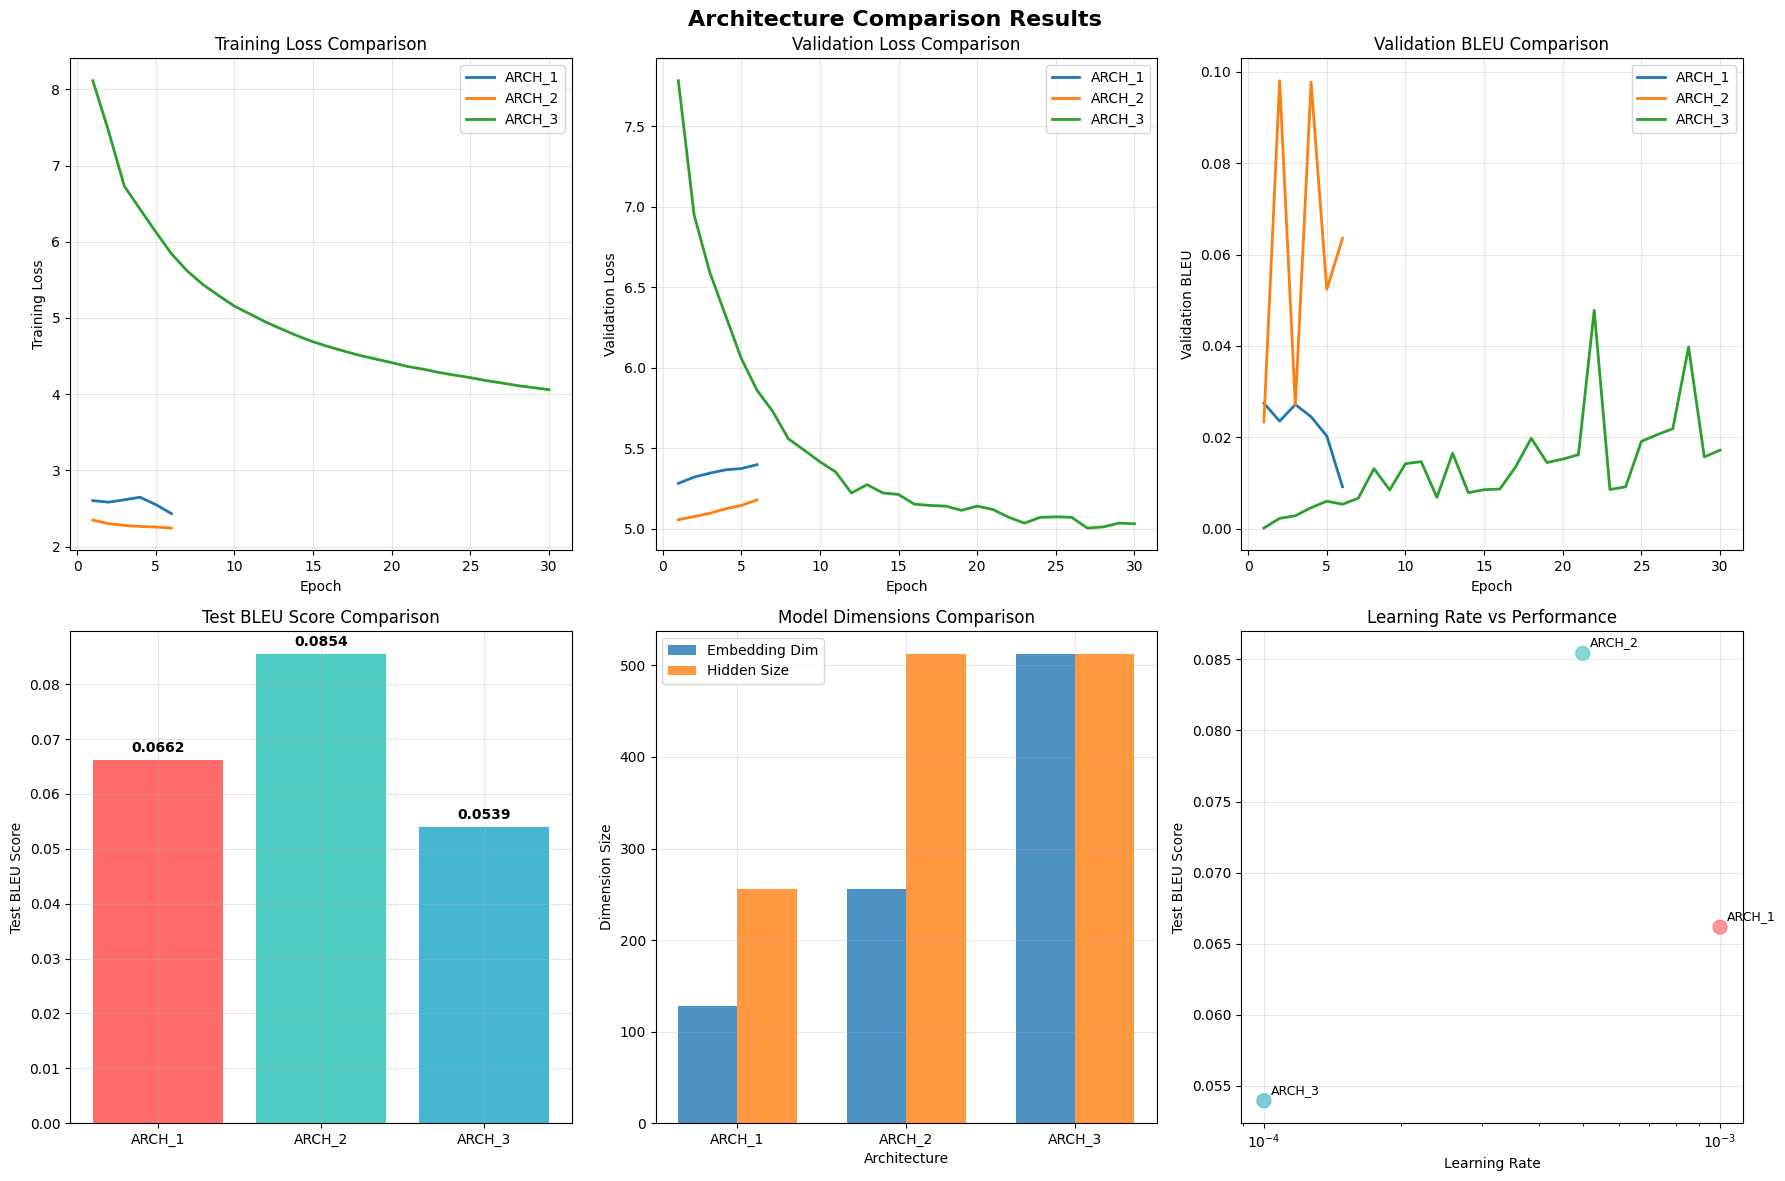


Visualization saved as 'three_architectures_comparison.png'

THREE ARCHITECTURE ANALYSIS COMPLETE!


In [17]:
# COMPREHENSIVE EVALUATION AND COMPARISON OF ALL THREE ARCHITECTURES
import editdistance
import matplotlib.pyplot as plt
import numpy as np

def evaluate_architecture_on_test(arch_name, results, data_dict):
    """Evaluate a trained architecture on test set"""
    print(f"\n{'='*60}")
    print(f"EVALUATING {arch_name} ON TEST SET")
    print(f"{'='*60}")
    
    # Load best model
    model = ALL_MODELS[arch_name]
    model.load_state_dict(results['best_model_state'])
    model.eval()
    
    # Create test loader
    _, _, test_loader = create_data_loaders(data_dict, ARCHITECTURES[arch_name])
    
    def translate_sentence(model, sentence, src_sp, tgt_sp, device, max_len=100):
        model.eval()
        with torch.no_grad():
            src_tokens = src_sp.encode(sentence, out_type=int)
            if len(src_tokens) == 0:
                return ""
                
            src = torch.tensor([src_tokens], dtype=torch.long).to(device)
            src_lens = torch.tensor([len(src_tokens)], dtype=torch.long).to(device)
            
            encoder_outputs, (encoder_hidden, encoder_cell) = model.encoder(src, src_lens)
            decoder_hidden, decoder_cell = model.init_decoder_states(encoder_hidden, encoder_cell)
            
            translated_tokens = [data_dict['BOS_ID']]
            input_token = torch.tensor([[data_dict['BOS_ID']]], dtype=torch.long).to(device)
            
            for _ in range(max_len):
                output, (decoder_hidden, decoder_cell) = model.decoder(
                    input_token, decoder_hidden, decoder_cell
                )
                
                next_token = output.argmax(dim=-1).item()
                translated_tokens.append(next_token)
                
                if next_token == data_dict['EOS_ID']:
                    break
                    
                input_token = torch.tensor([[next_token]], dtype=torch.long).to(device)
            
            translated_tokens = [t for t in translated_tokens[1:] if t != data_dict['EOS_ID']]
            return tgt_sp.decode(translated_tokens)
    
    # Test examples
    test_examples = [
        "زندگی تجھ پہ اب الزام کوئی کیا رکھے",
        "عاشقی میں میرؔ جیسے خواب مت دیکھا کرو", 
        "اب کے ہم بچھڑے تو شاید کبھی خوابوں میں ملیں",
        "دل میں کیا ہے محبت کے سوا اور کیا ہے",
        "یہ دنیا اک تماشا ہے جہاں ہر شخص اداکار"
    ]

    print(f"\n{arch_name} SAMPLE TRANSLATIONS:")
    print("-" * 40)
    for i, urdu_text in enumerate(test_examples, 1):
        translation = translate_sentence(model, urdu_text, data_dict['urdu_sp'], data_dict['roman_sp'], DEVICE, max_len=120)
        print(f"{i}. Urdu: {urdu_text}")
        print(f"   Roman: {translation}")
        print()

    # Comprehensive test evaluation
    bleu_scores = []
    cer_scores = []
    smooth = SmoothingFunction().method1

    print(f"Evaluating on {len(data_dict['test_pairs'])} test examples...")
    
    for i, (src_text, ref_text) in enumerate(data_dict['test_pairs']):
        pred_text = translate_sentence(model, src_text, data_dict['urdu_sp'], data_dict['roman_sp'], DEVICE, max_len=120)
        
        if pred_text:
            bleu = sentence_bleu([ref_text.split()], pred_text.split(), smoothing_function=smooth)
            bleu_scores.append(bleu)
            
            cer = editdistance.eval(list(ref_text), list(pred_text)) / max(1, len(ref_text))
            cer_scores.append(cer)
        
        # Print first few examples
        if i < 5:
            print(f"Example {i+1}:")
            print(f"  SRC:  {src_text}")
            print(f"  REF:  {ref_text}")  
            print(f"  PRED: {pred_text}")
            if pred_text:
                print(f"  BLEU: {bleu:.4f}, CER: {cer:.4f}")
            print()
        
        if (i + 1) % 200 == 0:
            print(f"  Processed {i+1} examples...")

    # Calculate final metrics
    avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0.0
    avg_cer = sum(cer_scores) / len(cer_scores) if cer_scores else 1.0

    return {
        'test_bleu': avg_bleu,
        'test_cer': avg_cer,
        'num_examples': len(bleu_scores)
    }

# Evaluate all architectures on test set
print("EVALUATING ALL ARCHITECTURES ON TEST SET...")
TEST_RESULTS = {}

for arch_name in ARCHITECTURES.keys():
    results = TRAINING_RESULTS[arch_name]
    data_dict = ALL_DATA[arch_name]
    test_metrics = evaluate_architecture_on_test(arch_name, results, data_dict)
    TEST_RESULTS[arch_name] = test_metrics

# Create comprehensive comparison
print(f"\n{'='*100}")
print("FINAL COMPREHENSIVE COMPARISON OF ALL THREE ARCHITECTURES")
print(f"{'='*100}")

comparison_data = []
for arch_name in ARCHITECTURES.keys():
    config = ARCHITECTURES[arch_name]
    train_results = TRAINING_RESULTS[arch_name]
    test_results = TEST_RESULTS[arch_name]
    
    comparison_data.append({
        'Architecture': arch_name,
        'Embed_Dim': config['embed_dim'],
        'Hidden_Size': config['hidden_size'],
        'Encoder_Layers': config['encoder_layers'],
        'Decoder_Layers': config['decoder_layers'],
        'Batch_Size': config['batch_size'],
        'Learning_Rate': config['learning_rate'],
        'Dropout': config['dropout'],
        'Best_Val_Loss': train_results['best_val_loss'],
        'Final_Train_Loss': train_results['history']['train_loss'][-1],
        'Final_Val_BLEU': train_results['history']['val_bleu'][-1],
        'Test_BLEU': test_results['test_bleu'],
        'Test_CER': test_results['test_cer']
    })

# Print detailed comparison table
print("\nDETAILED ARCHITECTURE COMPARISON:")
print("-" * 120)
print(f"{'Arch':<8} {'Embed':<6} {'Hidden':<7} {'Enc':<4} {'Dec':<4} {'Batch':<6} {'LR':<8} {'Drop':<5} {'Val_Loss':<9} {'Test_BLEU':<10} {'Test_CER':<8}")
print("-" * 120)

for data in comparison_data:
    print(f"{data['Architecture']:<8} {data['Embed_Dim']:<6} {data['Hidden_Size']:<7} {data['Encoder_Layers']:<4} {data['Decoder_Layers']:<4} "
          f"{data['Batch_Size']:<6} {data['Learning_Rate']:<8.0e} {data['Dropout']:<5} {data['Best_Val_Loss']:<9.4f} "
          f"{data['Test_BLEU']:<10.4f} {data['Test_CER']:<8.4f}")

# Find best architecture based on test BLEU
best_arch_by_bleu = max(comparison_data, key=lambda x: x['Test_BLEU'])
best_arch_by_loss = min(comparison_data, key=lambda x: x['Best_Val_Loss'])

print(f"\n{'='*80}")
print("FINAL RESULTS:")
print(f"{'='*80}")
print(f"Best Architecture by Test BLEU: {best_arch_by_bleu['Architecture']} (BLEU: {best_arch_by_bleu['Test_BLEU']:.4f})")
print(f"Best Architecture by Val Loss:  {best_arch_by_loss['Architecture']} (Loss: {best_arch_by_loss['Best_Val_Loss']:.4f})")
print(f"{'='*80}")

# Create visualization plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Architecture Comparison Results', fontsize=16, fontweight='bold')

# 1. Training Loss Comparison
ax = axes[0, 0]
for arch_name in ARCHITECTURES.keys():
    history = TRAINING_RESULTS[arch_name]['history']
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label=f'{arch_name}', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Validation Loss Comparison
ax = axes[0, 1]
for arch_name in ARCHITECTURES.keys():
    history = TRAINING_RESULTS[arch_name]['history']
    epochs = range(1, len(history['val_loss']) + 1)
    ax.plot(epochs, history['val_loss'], label=f'{arch_name}', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Validation BLEU Comparison
ax = axes[0, 2]
for arch_name in ARCHITECTURES.keys():
    history = TRAINING_RESULTS[arch_name]['history']
    epochs = range(1, len(history['val_bleu']) + 1)
    ax.plot(epochs, history['val_bleu'], label=f'{arch_name}', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation BLEU')
ax.set_title('Validation BLEU Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Test BLEU Bar Chart
ax = axes[1, 0]
arch_names = [data['Architecture'] for data in comparison_data]
test_bleus = [data['Test_BLEU'] for data in comparison_data]
bars = ax.bar(arch_names, test_bleus, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_ylabel('Test BLEU Score')
ax.set_title('Test BLEU Score Comparison')
ax.grid(True, alpha=0.3)
# Add value labels on bars
for bar, value in zip(bars, test_bleus):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{value:.4f}', 
            ha='center', va='bottom', fontweight='bold')

# 5. Parameter Configuration Comparison
ax = axes[1, 1]
embed_dims = [data['Embed_Dim'] for data in comparison_data]
hidden_sizes = [data['Hidden_Size'] for data in comparison_data]
x = np.arange(len(arch_names))
width = 0.35

bars1 = ax.bar(x - width/2, embed_dims, width, label='Embedding Dim', alpha=0.8)
bars2 = ax.bar(x + width/2, hidden_sizes, width, label='Hidden Size', alpha=0.8)
ax.set_xlabel('Architecture')
ax.set_ylabel('Dimension Size')
ax.set_title('Model Dimensions Comparison')
ax.set_xticks(x)
ax.set_xticklabels(arch_names)
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Hyperparameter vs Performance
ax = axes[1, 2]
learning_rates = [data['Learning_Rate'] for data in comparison_data]
test_bleus = [data['Test_BLEU'] for data in comparison_data]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

scatter = ax.scatter(learning_rates, test_bleus, c=colors, s=100, alpha=0.7)
for i, arch_name in enumerate(arch_names):
    ax.annotate(arch_name, (learning_rates[i], test_bleus[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Test BLEU Score')
ax.set_title('Learning Rate vs Performance')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('three_architectures_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved as 'three_architectures_comparison.png'")
print("\n" + "="*100)
print("THREE ARCHITECTURE ANALYSIS COMPLETE!")
print("="*100)

# Finding better architecture

In [31]:
# CELL 1 — CONFIG & IMPORTS (paste first)
import os, random, time, math
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import sentencepiece as spm
import nltk
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
nltk.download('punkt', quiet=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE ->", DEVICE)

# Paths - change if needed
URDU_TXT = "/kaggle/input/urduromanurdu-cleaned/all_urdu.txt"
ROMAN_TXT = "/kaggle/input/urduromanurdu-cleaned/all_english_clean.txt"
URDU_SPM_PREFIX = "/kaggle/working/urdu_tokenizer"
ROMAN_SPM_PREFIX = "/kaggle/working/roman_tokenizer"
SAVE_MODEL_PATH = "/kaggle/working/best_seq2seq_attention.pth"

# Best architecture + training hyperparams
CONFIG = {
    "embed_dim": 256,         # modest to avoid OOM
    "hidden_size": 256,
    "encoder_layers": 1,
    "decoder_layers": 2,
    "batch_size": 32,
    "learning_rate": 1e-3,    # lower LR (helps val)
    "weight_decay": 1e-2,
    "label_smoothing": 0.1,
    "dropout": 0.25,
    "num_epochs": 45,
    "patience": 6,
    "max_len": 120,
    "min_len": 2,
    "vocab_size": 5000,
    "seed": 42,
    "num_workers": 2,
    "warmup_steps": 2000,
    "max_grad_norm": 0.5,
    # scheduled sampling settings
    "ss_start": 0.0,    # start sampling probability (0 => pure teacher forcing)
    "ss_end": 0.7,      # end sampling prob (use model output that often)
    "ss_decay": 0.90,   # per-epoch multiplier (or use linear)
    "overfit_test": False, # set True to run tiny overfit test
}

# reproducibility
random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

print("Config loaded ✅")


DEVICE -> cuda
Config loaded ✅


In [32]:
# CELL 2 — TRAIN or LOAD SentencePiece (paste second)
def train_or_load_spm(input_txt, model_prefix, vocab_size=5000, model_type='bpe', character_coverage=0.995):
    model_file = model_prefix + ".model"
    if not os.path.exists(model_file):
        print(f"Training SentencePiece: {model_file} ...")
        spm.SentencePieceTrainer.train(
            input=input_txt,
            model_prefix=model_prefix,
            vocab_size=vocab_size,
            model_type=model_type,
            character_coverage=character_coverage,
            split_by_whitespace=True,
            normalization_rule_name='nfkc',
            remove_extra_whitespaces=True,
            pad_id=0, unk_id=1, bos_id=2, eos_id=3,
            pad_piece='<PAD>', unk_piece='<UNK>', bos_piece='<SOS>', eos_piece='<EOS>',
            user_defined_symbols=['<MASK>']
        )
        print("Trained:", model_file)
    else:
        print("Found tokenizer:", model_file)

    sp = spm.SentencePieceProcessor()
    sp.load(model_file)
    return sp

urdu_sp = train_or_load_spm(URDU_TXT, URDU_SPM_PREFIX, vocab_size=CONFIG["vocab_size"], model_type='bpe', character_coverage=0.995)
roman_sp = train_or_load_spm(ROMAN_TXT, ROMAN_SPM_PREFIX, vocab_size=CONFIG["vocab_size"], model_type='bpe', character_coverage=1.0)

print("Urdu vocab size:", urdu_sp.get_piece_size())
print("Roman vocab size:", roman_sp.get_piece_size())
# quick test
try:
    s = "تو کبھی خود کو بھی دیکھے گا"
    ids = urdu_sp.encode(s, out_type=int)
    print("Sample encode ok, len:", len(ids))
except Exception as e:
    print("SPM test error:", e)


Found tokenizer: /kaggle/working/urdu_tokenizer.model
Found tokenizer: /kaggle/working/roman_tokenizer.model
Urdu vocab size: 5000
Roman vocab size: 5000
Sample encode ok, len: 7


In [33]:
# CELL 3 — Data prep, model w/ Luong attention, scheduled sampling, train & save
# 80/10/10 split, train, eval, save

# ---------- read and split ----------
def read_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [l.strip() for l in f if l.strip()]

src_lines = read_lines(URDU_TXT)
tgt_lines = read_lines(ROMAN_TXT)
assert len(src_lines) == len(tgt_lines), "Mismatch lines!"

pairs = list(zip(src_lines, tgt_lines))
random.shuffle(pairs)
n = len(pairs)
train_end = int(0.8 * n); valid_end = int(0.9 * n)
train_pairs = pairs[:train_end]
valid_pairs = pairs[train_end:valid_end]
test_pairs  = pairs[valid_end:]
print(f"Counts -> total:{n}, train:{len(train_pairs)}, valid:{len(valid_pairs)}, test:{len(test_pairs)}")

# Optional overfit test
if CONFIG["overfit_test"]:
    print("Running tiny overfit test (10 pairs)...")
    train_pairs = train_pairs[:10]
    valid_pairs = train_pairs[:]  # same as train to test fit

# ---------- Dataset ----------
class SeqPairDataset(Dataset):
    def __init__(self, pairs, src_sp, tgt_sp, max_len, min_len):
        self.pairs = [p for p in pairs if len(src_sp.encode(p[0]))>=min_len and len(tgt_sp.encode(p[1]))>=min_len]
        self.src_sp = src_sp; self.tgt_sp = tgt_sp; self.max_len = max_len

    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        s,t = self.pairs[idx]
        s_ids = self.src_sp.encode(s, out_type=int)[:self.max_len-2]
        t_ids = self.tgt_sp.encode(t, out_type=int)[:self.max_len-2]
        t_in = [self.tgt_sp.bos_id()] + t_ids
        t_out = t_ids + [self.tgt_sp.eos_id()]
        return {"src": torch.tensor(s_ids, dtype=torch.long),
                "tgt_in": torch.tensor(t_in, dtype=torch.long),
                "tgt_out": torch.tensor(t_out, dtype=torch.long),
                "src_len": len(s_ids)}

def collate_fn(batch):
    srcs = [b["src"] for b in batch]
    tins = [b["tgt_in"] for b in batch]
    touts = [b["tgt_out"] for b in batch]
    src_lens = torch.tensor([b["src_len"] for b in batch], dtype=torch.long)
    src_p = pad_sequence(srcs, batch_first=True, padding_value=urdu_sp.pad_id())
    tin_p = pad_sequence(tins, batch_first=True, padding_value=roman_sp.pad_id())
    tout_p= pad_sequence(touts, batch_first=True, padding_value=roman_sp.pad_id())
    return {"src": src_p, "tgt_in": tin_p, "tgt_out": tout_p, "src_lens": src_lens}

train_loader = DataLoader(SeqPairDataset(train_pairs, urdu_sp, roman_sp, CONFIG["max_len"], CONFIG["min_len"]),
                          batch_size=CONFIG["batch_size"], shuffle=True, collate_fn=collate_fn, num_workers=CONFIG["num_workers"])
valid_loader = DataLoader(SeqPairDataset(valid_pairs, urdu_sp, roman_sp, CONFIG["max_len"], CONFIG["min_len"]),
                          batch_size=CONFIG["batch_size"], shuffle=False, collate_fn=collate_fn, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(SeqPairDataset(test_pairs, urdu_sp, roman_sp, CONFIG["max_len"], CONFIG["min_len"]),
                          batch_size=1, shuffle=False, collate_fn=collate_fn)

print("Dataloaders ready ✅")

# ---------- Model with Luong attention ----------
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True, bidirectional=True, dropout=dropout if n_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout)
    def forward(self, src, src_lens):
        emb = self.dropout(self.embedding(src))
        packed = pack_padded_sequence(emb, src_lens.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h,c) = self.rnn(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)
        return out, (h,c)

class DecoderWithLuong(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hid, n_layers, dropout, pad_idx, enc_hid2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(emb_dim, dec_hid, n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0.0)
        # project decoder hidden -> encoder hidden*2 (for dot product)
        self.attn_proj = nn.Linear(dec_hid, enc_hid2)
        # final output: concat(rnn_out, context) -> vocab
        self.out = nn.Linear(dec_hid + enc_hid2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs):
        # input_token: (batch,1)
        emb = self.dropout(self.embedding(input_token))                # (batch,1,emb)
        rnn_out, (nh, nc) = self.rnn(emb, (hidden, cell))              # rnn_out: (batch,1,dec_hid)
        rnn_out_s = rnn_out.squeeze(1)                                # (batch, dec_hid)
        # attention scores
        # project hidden to encoder space
        proj = self.attn_proj(nh[-1])                                 # (batch, enc_hid2)
        # energy: (batch, src_len) = bmm(encoder_outputs, proj.unsqueeze(2)).squeeze(2)
        energy = torch.bmm(encoder_outputs, proj.unsqueeze(2)).squeeze(2)
        attn_weights = torch.softmax(energy, dim=1)                   # (batch, src_len)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # (batch, enc_hid2)
        concat = torch.cat([rnn_out_s, context], dim=1)               # (batch, dec_hid+enc_hid2)
        logits = self.out(concat)                                     # (batch, vocab)
        return logits, (nh, nc), attn_weights

class Seq2SeqAttention(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc
        self.dec = dec
    def init_decoder_states(self, eh, ec):
        enc_layers = eh.size(0) // 2
        forward_h = eh[enc_layers-1]; backward_h = eh[-1]
        forward_c = ec[enc_layers-1]; backward_c = ec[-1]
        final_h = torch.cat([forward_h, backward_h], dim=1)   # (batch, enc_hid*2)
        final_c = torch.cat([forward_c, backward_c], dim=1)
        # project to decoder dims (repeat for each dec layer)
        dec_layers = self.dec.rnn.num_layers
        # use linear mapping for state init
        proj_h = nn.Linear(final_h.size(1), self.dec.rnn.hidden_size).to(DEVICE)
        proj_c = nn.Linear(final_c.size(1), self.dec.rnn.hidden_size).to(DEVICE)
        dh = proj_h(final_h).unsqueeze(0).repeat(dec_layers, 1, 1)
        dc = proj_c(final_c).unsqueeze(0).repeat(dec_layers, 1, 1)
        return dh, dc

    def forward(self, src, src_lens, tgt_in, ss_prob=0.0, teacher_forcing=True):
        batch = src.size(0)
        vocab = self.dec.out.out_features
        enc_out, (eh, ec) = self.enc(src, src_lens)
        # init decoder states (simple projection, not learned across calls)
        dh, dc = self.init_decoder_states(eh, ec)
        outputs = torch.zeros(batch, tgt_in.size(1), vocab).to(DEVICE)
        input_tok = tgt_in[:,0:1]
        for t in range(1, tgt_in.size(1)):
            logits, (dh, dc), _ = self.dec(input_tok, dh, dc, enc_out)
            outputs[:, t] = logits
            use_model = (random.random() < ss_prob) and teacher_forcing  # sample usage
            if use_model:
                input_tok = logits.argmax(dim=-1, keepdim=True)
            else:
                input_tok = tgt_in[:, t:t+1]
        return outputs

# ---------- instantiate model ----------
enc = Encoder(urdu_sp.get_piece_size(), CONFIG["embed_dim"], CONFIG["hidden_size"], CONFIG["encoder_layers"], CONFIG["dropout"], urdu_sp.pad_id())
# enc output dim = hidden_size * 2
dec = DecoderWithLuong(roman_sp.get_piece_size(), CONFIG["embed_dim"], CONFIG["hidden_size"], CONFIG["decoder_layers"], CONFIG["dropout"], roman_sp.pad_id(), enc_hid2=CONFIG["hidden_size"]*2)
model = Seq2SeqAttention(enc, dec).to(DEVICE)
print("Model params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---------- optimizer, scheduler, loss ----------
optimizer = optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
def get_lr_scheduler(optim_, warmup, total_steps):
    def lr_lambda(step):
        if step < warmup:
            return float(step) / max(1, warmup)
        return (warmup ** 0.5) * (step ** -0.5)
    return optim.lr_scheduler.LambdaLR(optim_, lr_lambda)
total_steps = max(1, len(train_loader) * CONFIG["num_epochs"])
scheduler = get_lr_scheduler(optimizer, CONFIG["warmup_steps"], total_steps)
criterion = nn.CrossEntropyLoss(ignore_index=roman_sp.pad_id(), label_smoothing=CONFIG["label_smoothing"])

# ---------- helpers ----------
def evaluate(model_, loader):
    model_.eval()
    total_loss = 0.0; total = 0
    with torch.no_grad():
        for batch in loader:
            src = batch["src"].to(DEVICE); src_lens = batch["src_lens"].to(DEVICE)
            tin = batch["tgt_in"].to(DEVICE); tout = batch["tgt_out"].to(DEVICE)
            out = model_.forward(src, src_lens, tin, ss_prob=0.0, teacher_forcing=False)
            loss = criterion(out[:,1:,:].reshape(-1,out.size(-1)), tout[:,1:].reshape(-1))
            total_loss += loss.item() * src.size(0); total += src.size(0)
    return total_loss / max(1, total)

def translate(model_, sentence, max_len=100):
    model_.eval()
    with torch.no_grad():
        src_ids = urdu_sp.encode(sentence, out_type=int)
        if len(src_ids)==0: return ""
        src = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)
        src_lens = torch.tensor([len(src_ids)], dtype=torch.long).to(DEVICE)
        # build dummy tgt_in with BOS and max_len-1 pads
        tgt_in = torch.tensor([[roman_sp.bos_id()] + [roman_sp.pad_id()]*(max_len-1)], dtype=torch.long).to(DEVICE)
        out = model_.forward(src, src_lens, tgt_in, ss_prob=1.0, teacher_forcing=False)
        preds = out.argmax(dim=-1)[0].cpu().tolist()
        # remove BOS and tokens after EOS
        if roman_sp.eos_id() in preds:
            preds = preds[:preds.index(roman_sp.eos_id())]
        return roman_sp.decode(preds[1:]) if preds and preds[0]==roman_sp.bos_id() else roman_sp.decode(preds)

# ---------- training loop with scheduled sampling ----------
best_val = float('inf'); best_state = None; patience_ctr = 0
ss_prob = CONFIG["ss_start"]

for epoch in range(1, CONFIG["num_epochs"]+1):
    model.train()
    epoch_loss = 0.0; batches = 0
    # update scheduled sampling prob (linear ramp):
    ss_prob = min(CONFIG["ss_end"], CONFIG["ss_start"] + (CONFIG["ss_end"]-CONFIG["ss_start"])*(epoch/CONFIG["num_epochs"]))
    # alternate: decay multiplier (not used now)
    for batch in train_loader:
        src = batch["src"].to(DEVICE); src_lens = batch["src_lens"].to(DEVICE)
        tin = batch["tgt_in"].to(DEVICE); tout = batch["tgt_out"].to(DEVICE)

        optimizer.zero_grad()
        out = model.forward(src, src_lens, tin, ss_prob=ss_prob, teacher_forcing=True)
        loss = criterion(out[:,1:,:].reshape(-1,out.size(-1)), tout[:,1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item(); batches += 1

    avg_train = epoch_loss / max(1, batches)
    val_loss = evaluate(model, valid_loader)

    print(f"Epoch {epoch}: Train={avg_train:.4f} Val={val_loss:.4f} SS={ss_prob:.3f} LR={scheduler.get_last_lr()[0]:.2e}")

    # early save
    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        torch.save({"model_state_dict": best_state, "config": CONFIG}, SAVE_MODEL_PATH)
        print("  -> New best model saved.")
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= CONFIG["patience"]:
            print("Early stopping.")
            break

print("Training done. Best val loss:", best_val)

# ---------- sample translations ----------
print("\nSample valid translations:")
sample_n = min(5, len(valid_pairs))
for i in range(sample_n):
    s, r = valid_pairs[i]
    p = translate(model, s)
    print(f"SRC: {s[:80]}\nREF: {r[:80]}\nPRED: {p[:120]}\n---")

print("Saved model:", SAVE_MODEL_PATH)
print("Saved tokenizers:", URDU_SPM_PREFIX + ".model", ROMAN_SPM_PREFIX + ".model")


Counts -> total:21000, train:16800, valid:2100, test:2100
Dataloaders ready ✅
Model params: 8641928
Epoch 1: Train=7.1105 Val=6.2370 SS=0.016 LR=2.63e-04
  -> New best model saved.
Epoch 2: Train=5.7584 Val=5.1585 SS=0.031 LR=5.25e-04
  -> New best model saved.
Epoch 3: Train=4.6979 Val=4.2675 SS=0.047 LR=7.88e-04
  -> New best model saved.
Epoch 4: Train=3.9175 Val=3.7795 SS=0.062 LR=9.76e-04
  -> New best model saved.
Epoch 5: Train=3.3593 Val=3.4864 SS=0.078 LR=8.73e-04
  -> New best model saved.
Epoch 6: Train=3.0008 Val=3.2669 SS=0.093 LR=7.97e-04
  -> New best model saved.
Epoch 7: Train=2.7516 Val=3.1779 SS=0.109 LR=7.38e-04
  -> New best model saved.
Epoch 8: Train=2.5638 Val=3.0899 SS=0.124 LR=6.90e-04
  -> New best model saved.
Epoch 9: Train=2.4360 Val=3.0369 SS=0.140 LR=6.51e-04
  -> New best model saved.
Epoch 10: Train=2.3236 Val=3.0164 SS=0.156 LR=6.17e-04
  -> New best model saved.
Epoch 11: Train=2.2394 Val=3.0155 SS=0.171 LR=5.88e-04
  -> New best model saved.
Epoch 1

# Conclusion and Remarks:
from above experiements we can see there there is high Validation loss and Low BLEU and reson may include:
1. Smaller data set. Our data set contains only 12k lines.Model starts to overfit as we try to increase model complexity additionally it was observed that if we change split from 50 training 25 validation and testing data to 80% 10% 10% our results are improved.
2. We have use L2 regularization in adam to cater overfitting issue.
3. Bi LSTM and LSTM architecture is weaker for such cases. Attention and Self attention is needed for such cases